In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import least_squares, fsolve
from scipy.special import erfc

In [2]:
mpl.rcParams['figure.dpi'] = 150

In [3]:
def read_transition(filename, mu_min_data=-np.inf, mu_max_data=np.inf, mu_min_fit=-np.inf, mu_max_fit=np.inf, 
                    column_mu=0, columns_sigma=(1,2), skiprows=0, least_spacing=0.01):
    columns = (column_mu,) + columns_sigma
    data = np.loadtxt(filename, usecols=columns, skiprows=skiprows)
    data = data[(data[:,0] >= mu_min_data) & (data[:,0] <= mu_max_data)]
    answer = [[data[0,0], (data[0,1] + data[0,2]) / 2, data[0,2] - data[0,1]]]
    for i in range(1, len(data)):
        if data[i,0] - answer[-1][0] >= least_spacing:
            answer.append([data[i,0], (data[i,1] + data[i,2]) / 2, data[i,2] - data[i,1]])

    data_filtered = data[(data[:,0] >= mu_min_fit) & (data[:,0] <= mu_max_fit)]
    answer_filtered = [[data_filtered[0,0], (data_filtered[0,1] + data_filtered[0,2]) / 2, data_filtered[0,2] - data_filtered[0,1]]]
    for i in range(1, len(data_filtered)):
        if data_filtered[i,0] - answer_filtered[-1][0] >= least_spacing:
            answer_filtered.append([data_filtered[i,0], (data_filtered[i,1] + data_filtered[i,2]) / 2, data_filtered[i,2] - data_filtered[i,1]])
    return np.array(answer), np.array(answer_filtered)

In [4]:
def read_all_transitions(N_list, path, eps, lda, tol_fixed_point, c, T, 
                         mu_min_data=-np.inf, mu_max_data=np.inf, mu_min_fit=-np.inf, mu_max_fit=np.inf, 
                         colum_mu=0, columns_sigma=(1,2), skiprows=0, least_spacing=0.01):
    all_data = {}
    all_data_filtered = {}
    for N in N_list:
        filename = f'{path}/Lotka-Volterra_transition_div_fit_sigmoid_epsilon_{eps}_Partially_AsymGauss_lambda_{lda}_tol_{tol_fixed_point}_N_{N}_c_{c}_T_{T}.txt'
        data, data_filtered = read_transition(filename, mu_min_data=mu_min_data, mu_max_data=mu_max_data, mu_min_fit=mu_min_fit, 
                                              mu_max_fit=mu_max_fit, column_mu=colum_mu, columns_sigma=columns_sigma, 
                                              skiprows=skiprows, least_spacing=least_spacing)
        all_data[N] = data
        all_data_filtered[N] = data_filtered
    return all_data, all_data_filtered

In [5]:
def sigma_afer_linearization(mu_values, N, A, c):
    return np.sqrt(1 + mu_values * c) / (A* np.sqrt(np.log(N))) 

In [6]:
def function_to_find_root(sigma, mu, c, N, A):
    return sigma ** 2 * np.exp(-((1 + mu * np.sqrt(c)) / sigma) ** 2) - \
           np.sqrt(np.pi * c) * mu * sigma * erfc((1 + mu * np.sqrt(c)) / sigma) - \
           A / N

def function_to_find_root2(sigma, mu, c, N, A):
    return sigma ** 2 *  np.log(sigma ** 2 / (1 + mu * np.sqrt(c))) + A * sigma ** 2 * np.log(N) - (1 + mu * np.sqrt(c)) ** 2

def function_to_find_root3(sigma, mu, c, N, A):
    return A * N * sigma ** 2 / (1 + mu * np.sqrt(c)) - np.exp(((1 + mu * np.sqrt(c)) / sigma) ** 2)


def sigma_without_linearization(mu_values, N, A, c, sigma0=0.1):
    anwser = []
    for mu in mu_values:
        anwser.append(fsolve(function_to_find_root3, sigma0, args=(mu, c, N, A))[0])
    return np.array(anwser)

In [7]:
def residuals(A, c, all_data, unique_A=False, min_N=0, weights=None, sigma_predictor=sigma_afer_linearization):
    if weights is None:
        weights = {}
        for N in all_data:
            weights[N] = 1.0
    counter = 0
    res = []
    for N in all_data:
        if N > min_N:
            data = all_data[N]
            mu_values = data[:,0]
            observed_sigma = data[:,1]
            if unique_A:
                predicted_sigma = sigma_predictor(mu_values, N, A, c)
            else:
                predicted_sigma = sigma_predictor(mu_values, N, A[counter], c)
                counter += 1
            res.extend((observed_sigma - predicted_sigma) * weights[N])
    return np.array(res)

In [8]:
def make_fit(c, all_data, initial_guess, unique_A=False, min_N=0, weights=None, sigma_predictor=sigma_afer_linearization):
    result = least_squares(residuals, initial_guess, args=(c, all_data, unique_A, min_N, weights, sigma_predictor))
    print("Optimized parameters:", result.x)
    print("Cost function value:", result.cost / len(all_data.keys()))
    return result.x

In [9]:
def plot_fits(all_data, min_mu, optimized_A, c, figname=None, unique_A=False, sigma_predictor=sigma_afer_linearization):
    plt.figure()
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for idx, N in enumerate(all_data):
        color = color_cycle[idx % len(color_cycle)]
        data = all_data[N]
        mu_values = data[:,0]
        mu_values_plot = np.linspace(min_mu, max(mu_values), 1000)
        observed_sigma = data[:,1]
        errors = data[:,2]
        plt.scatter(mu_values, observed_sigma, label=f'N={N}', color=color, s=10)
        plt.errorbar(mu_values, observed_sigma, yerr=errors, color=color, linestyle='None', capsize=2, alpha=0.5)
        if unique_A:
            predicted_sigma = sigma_predictor(mu_values_plot, N, optimized_A, c)
        else:
            predicted_sigma = sigma_predictor(mu_values_plot, N, optimized_A[idx], c)
        plt.plot(mu_values_plot, predicted_sigma, color=color)
    plt.xlabel(r'$\mu$')
    plt.ylabel(r'$\sigma$')
    plt.legend()
    plt.text(0.3, 0.85, "UNBOUNDED\nGROWTH", fontsize=16, transform=plt.gca().transAxes, 
             verticalalignment='top', horizontalalignment='center')
    if figname is not None:
        plt.savefig(figname, dpi=400)

In [10]:
eps = "0.0"
lda = "1e-06"
N_list = [512, 1024, 2048, 4096, 8192, 16384, 32768]
c = "3.00"
T = "0.0"
tol_fixed_point = "1e-08"

# path = "/media/david/Seagate Expansion Drive/Salva/Salva_Data_Investigacion/Grupo_de_investigacion/Ecology/Langevin/Results/"
path = "/mnt/d/Research/Ecology/Langevin/Results/"

In [11]:
mu_min_fit = -0.2
mu_max_data = 0.37
all_data, all_data_filtered = read_all_transitions(N_list, path, eps, lda, tol_fixed_point, c, T, 
                                                   mu_max_data=mu_max_data, mu_min_fit=mu_min_fit, least_spacing=0.029)

Optimized parameters: [0.90625925 0.91941312 0.93074437 0.94061845 0.94855762 0.95308264
 0.95953375]
Cost function value: 0.0003754249884139601


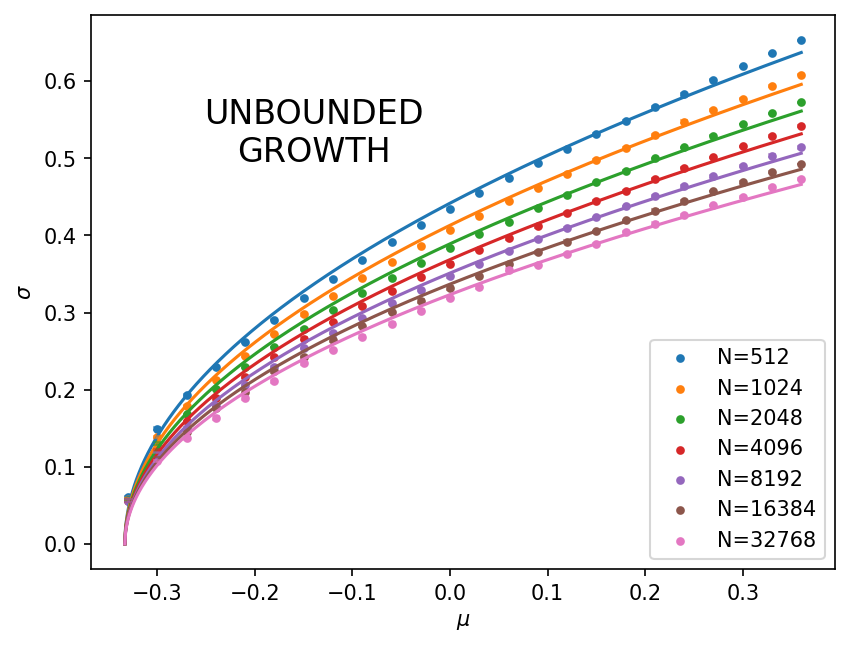

In [12]:
Ainit = [1.0 for _ in N_list]
optimized_A = make_fit(float(c), all_data_filtered, Ainit, unique_A=False, sigma_predictor=sigma_afer_linearization)
min_mu_plot = -1.0 / float(c)
plot_fits(all_data, min_mu_plot, optimized_A, float(c), unique_A=False, sigma_predictor=sigma_afer_linearization)

Optimized parameters: [0.95207451]
Cost function value: 6.5407031472293085


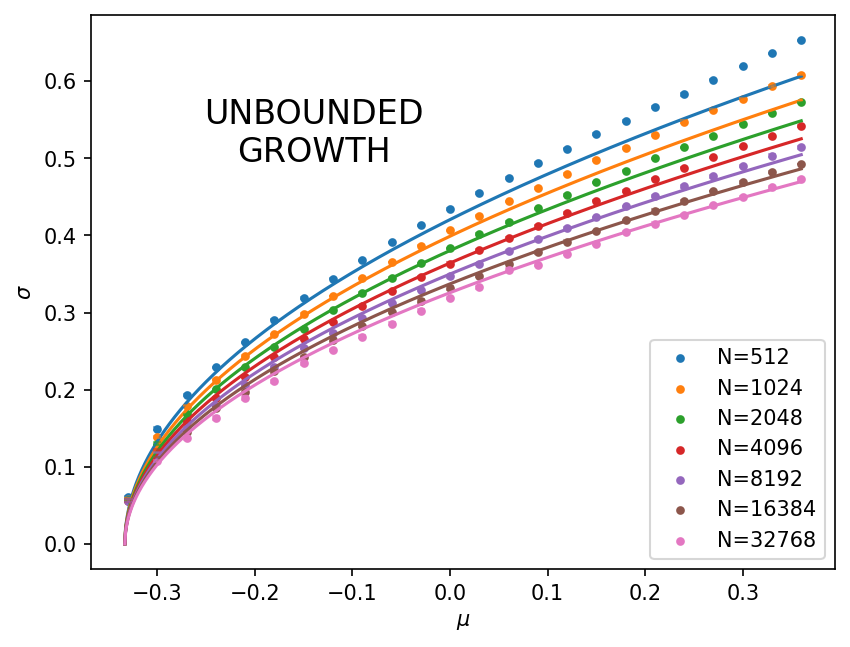

In [13]:
Ainit = 1.0
min_N = 2048
weights = {N: np.log2(N) ** 2 for N in N_list}
optimized_A = make_fit(float(c), all_data_filtered, Ainit, unique_A=True, min_N=min_N, weights=weights, sigma_predictor=sigma_afer_linearization)
min_mu_plot = -1.0 / float(c)
# path = "/media/david/Seagate Expansion Drive/Salva/Salva_Data_Investigacion/Grupo_de_investigacion/Ecology/Results/Plots_RRG"
path = "/mnt/d/Research/Ecology/Results/Plots_RRG"
figname = f'{path}/RMT_fit_Simulations_sigma_vs_mu_Unbounded_Growth.png'
plot_fits(all_data, min_mu_plot, optimized_A, float(c), figname=figname, unique_A=True, sigma_predictor=sigma_afer_linearization)

Optimized parameters: [ 2.72188598  3.53589916  4.58058877  5.92137048  7.46024366  8.92374754
 11.290592  ]
Cost function value: 0.0006826479452726583


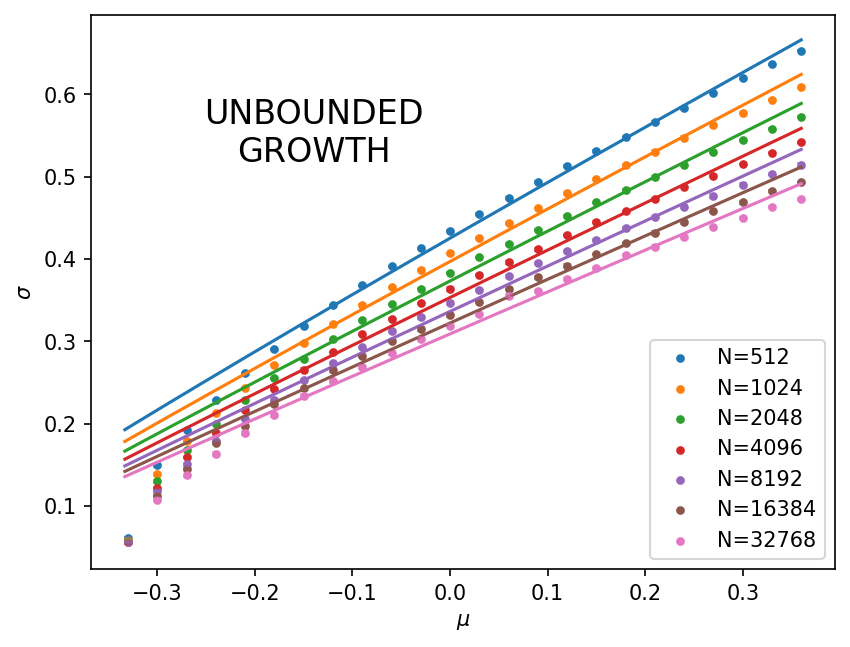

In [14]:
Ainit = [1 for _ in N_list]
optimized_A = make_fit(float(c), all_data_filtered, Ainit, unique_A=False, sigma_predictor=sigma_without_linearization)
min_mu_plot = -1.0 / float(c)
plot_fits(all_data, min_mu_plot, optimized_A, float(c), unique_A=False, sigma_predictor=sigma_without_linearization)